# ARCFRESH — Gate Analysis Notebook

Self-contained **raw gate NetCDF** files (one per gate, daily axis 2002–2023).

**Data stack in each gate file:**
| Variable | Source | Temporal | Spatial |
|---|---|---|---|
| `ugos`, `vgos` | CMEMS L4 DUACS | Daily | 0.125° remapped to gate points |
| `err_ugosa`, `err_vgosa` | CMEMS L4 formal mapping error | Daily | 0.125° remapped |
| `sss`, `sss_random_error` | ESA CCI SSS v5.5 | Monthly (1+15 aggregated) mapped to daily | remapped along gate |
| `psal_isas_surface` | ISAS climatology (PSAL z0) | Monthly climatology mapped to daily | remapped along gate |
| `depth` | GEBCO 2025 | Static | gate points |
| `dx`, `x_km`, `longitude`, `latitude` | Gate geometry | Static | gate points |

## Physics convention used here (new local method)
For each gate point `i`, the local tangent is computed from neighboring coordinates and converted into a local normal toward Arctic side:

`v⊥(i,t) = ugos(i,t) * u_into_local(i) + vgos(i,t) * v_into_local(i)`

- `ugos`: eastward positive
- `vgos`: northward positive
- `v⊥ > 0`: inflow toward Arctic side of the gate

No `theta` field is read from NetCDF.

In [21]:
# Cell 1 — Packages & helpers (Plotly-first)
import numpy as np
import pandas as pd
import xarray as xr
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from pathlib import Path
import importlib, warnings

warnings.filterwarnings('ignore', 'Mean of empty slice')

# Local utils (reload to pick up any changes)
import utils as _u
importlib.reload(_u)
from utils import (
    load_gate, list_available_gates,
    local_into_arctic_unit_vectors,
    perpendicular_velocity, perpendicular_velocity_uncertainty,
    volume_transport, volume_transport_uncertainty,
    volume_transport_per_point, volume_transport_per_point_uncertainty,
    freshwater_transport, freshwater_transport_uncertainty,
    freshwater_transport_per_point, freshwater_transport_per_point_uncertainty,
    salt_flux, salt_flux_uncertainty,
    salt_flux_per_point, salt_flux_per_point_uncertainty,
    monthly_mean, monthly_climatology, annual_mean,
    monthly_along_gate_profile,
    SVERDRUP, DEPTH_CAP, MONTH_NAMES,
)


def _month_rc(month_idx: int) -> tuple[int, int]:
    return (month_idx - 1) // 3 + 1, (month_idx - 1) % 3 + 1


def plot_monthly_grid(
    x_km,
    profiles,
    y_label,
    color,
    title,
    band_label='± std dev',
    zero_line=True,
):
    fig = make_subplots(
        rows=4,
        cols=3,
        shared_xaxes=True,
        shared_yaxes=True,
        subplot_titles=[MONTH_NAMES[i] for i in range(12)],
        vertical_spacing=0.06,
        horizontal_spacing=0.04,
    )

    for m in range(1, 13):
        row, col = _month_rc(m)
        p = profiles[m]
        mean = np.asarray(p['mean'], dtype=float)
        std = np.asarray(p['std'], dtype=float)

        valid = np.isfinite(mean) & np.isfinite(std)
        if np.any(valid):
            x_band = np.concatenate([x_km[valid], x_km[valid][::-1]])
            y_band = np.concatenate([(mean[valid] - std[valid]), (mean[valid] + std[valid])[::-1]])
            fig.add_trace(
                go.Scatter(
                    x=x_band,
                    y=y_band,
                    fill='toself',
                    fillcolor='rgba(70,130,180,0.20)' if color == 'steelblue' else 'rgba(0,0,0,0.12)',
                    line=dict(color='rgba(0,0,0,0)'),
                    name=band_label,
                    showlegend=(m == 1),
                    hoverinfo='skip',
                ),
                row=row,
                col=col,
            )

        fig.add_trace(
            go.Scatter(
                x=x_km,
                y=mean,
                mode='lines',
                line=dict(color=color, width=2),
                name='mean profile',
                showlegend=False,
            ),
            row=row,
            col=col,
        )

        if zero_line:
            fig.add_hline(y=0.0, line=dict(color='rgba(80,80,80,0.6)', width=1, dash='dash'), row=row, col=col)

        fig.layout.annotations[m - 1].text = f"{MONTH_NAMES[m-1]} (n={p['count']})"

    for c in range(1, 4):
        fig.update_xaxes(title_text='Distance along gate (km)', row=4, col=c)
    for r in range(1, 5):
        fig.update_yaxes(title_text=y_label, row=r, col=1)

    fig.update_layout(
        title=title,
        height=980,
        template='plotly_white',
        legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='right', x=1),
        margin=dict(t=90),
    )
    fig.show()


print('✅ Ready (Plotly + local per-point projection)')

✅ Ready


In [22]:
# Cell 2 — List available NetCDF files
PRIMARY_NC_DIR = Path('/Users/nicolocaron/Desktop/ARCFRESH/NETCDF CODE')
FALLBACK_NC_DIR = Path('../data/netcdf')

if PRIMARY_NC_DIR.exists():
    NC_DIR = PRIMARY_NC_DIR
elif FALLBACK_NC_DIR.exists():
    NC_DIR = FALLBACK_NC_DIR
else:
    raise FileNotFoundError('No NetCDF directory found (checked PRIMARY_NC_DIR and FALLBACK_NC_DIR).')

print(f'Using NC_DIR = {NC_DIR}')
for f in list_available_gates(NC_DIR):
    size_mb = (NC_DIR / f).stat().st_size / 1e6
    print(f'  {f}  ({size_mb:.1f} MB)')

  arcfresh_barents_opening_2002-2023.nc  (12.3 MB)
  arcfresh_barents_sea_cao_2002-2023.nc  (21.6 MB)
  arcfresh_barents_sea_kara_sea_2002-2023.nc  (3.7 MB)
  arcfresh_beaufort_sea_caa_2002-2023.nc  (4.2 MB)
  arcfresh_beaufort_sea_cao_2002-2023.nc  (22.9 MB)
  arcfresh_bering_strait_2002-2023.nc  (2.2 MB)
  arcfresh_caa_cao_2002-2023.nc  (14.9 MB)
  arcfresh_davis_strait_2002-2023.nc  (6.8 MB)
  arcfresh_denmark_strait_2002-2023.nc  (8.2 MB)
  arcfresh_ess_beaufort_sea_2002-2023.nc  (7.7 MB)
  arcfresh_ess_cao_2002-2023.nc  (192.3 MB)
  arcfresh_fram_strait_2002-2023.nc  (19.2 MB)
  arcfresh_jones_sound_2002-2023.nc  (0.7 MB)
  arcfresh_kara_sea_cao_2002-2023.nc  (17.9 MB)
  arcfresh_kara_sea_laptev_sea_2002-2023.nc  (4.0 MB)
  arcfresh_lancaster_sound_2002-2023.nc  (0.7 MB)
  arcfresh_laptev_sea_cao_2002-2023.nc  (23.7 MB)
  arcfresh_laptev_sea_ess_2002-2023.nc  (4.6 MB)
  arcfresh_nares_strait_2002-2023.nc  (5.2 MB)
  arcfresh_norwegian_boundary_2002-2023.nc  (14.9 MB)


In [ ]:
# ══════════════════════════════════════════════════════════════
# INPUTS — change these
# ══════════════════════════════════════════════════════════════
GATE_ID    = 'davis_strait'
DATE_START = '2010-01-01'
DATE_END   = '2023-12-31'
CAP        = 250          # depth cap (m)
S_REF      = 34.8         # reference salinity (PSU)
RHO        = 1025.0       # seawater density (kg/m³)

# ── Load & slice ──
nc_file = NC_DIR / f'arcfresh_{GATE_ID}_2002-2023.nc'
ds = load_gate(nc_file).sel(time=slice(DATE_START, DATE_END))

gate_name = ds.attrs.get('gate_display_name', GATE_ID)
x_km      = ds['x_km'].values
time      = pd.to_datetime(ds['time'].values)

has_cci  = bool(int(ds.attrs.get('has_cci', 0))) and ('sss' in ds)
has_isas = bool(int(ds.attrs.get('has_isas', 0))) and ('psal_isas_surface' in ds)
has_sss  = ('sss' in ds) and bool(np.isfinite(ds['sss'].values).any())

lon = ds['longitude'].values
lat = ds['latitude'].values

print(f'╔══════════════════════════════════════════════════╗')
print(f'  Gate    : {gate_name}')
print(f'  Region  : {ds.attrs.get("region", "—")}')
print(f'  Points  : {ds.dims["point"]}  |  Days: {ds.dims["time"]}')
print(f'  Period  : {str(time[0].date())} → {str(time[-1].date())}')
print(f'  Length  : {x_km[-1]:.1f} km')
print(f'  Lon     : {lon[0]:.2f}° → {lon[-1]:.2f}°')
print(f'  Lat     : {lat[0]:.2f}° → {lat[-1]:.2f}°')
print(f'  Velocity: CMEMS L4 daily 0.125° (DUACS v202411)')
print(f'  Bathy   : GEBCO 2025 (15 arc-sec)')
print(f'  CCI SSS : {"AVAILABLE" if has_cci else "NOT AVAILABLE"}')
print(f'  ISAS z0 : {"AVAILABLE" if has_isas else "NOT AVAILABLE"}')
print(f'  Cap     : {CAP} m  |  S_ref: {S_REF} PSU  |  ρ: {RHO} kg/m³')
print(f'╚══════════════════════════════════════════════════╝')

╔══════════════════════════════════════════════════╗
  Gate    : Davis Strait
  Region  : Arctic Ocean (external boundaries)
  Points  : 92  |  Days: 5113
  Period  : 2010-01-01 → 2023-12-31
  Length  : 479.6 km
  Lon     : -64.40° → -52.98° (W→E ✅)
  θ angle : 0.0°
  Velocity: CMEMS L4 daily 0.125° (DUACS v202411)
  Bathy   : GEBCO 2025 (15 arc-sec)
  SSS     : CCI v5.5 semi-monthly (day 1 & 15)
  Cap     : 250 m  |  S_ref: 34.8 PSU  |  ρ: 1025.0 kg/m³
╚══════════════════════════════════════════════════╝


/var/folders/q5/g4rsymgj6137bp73lx06r3g40000gn/T/ipykernel_71776/3949515506.py:24: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(f'  Points  : {ds.dims["point"]}  |  Days: {ds.dims["time"]}')


---
## 1 · Geostrophic Velocity (Local Per-Point Projection)
`v⊥(i,t) = ugos(i,t)·u_into_local(i) + vgos(i,t)·v_into_local(i)` — positive = into Arctic side.

- `ugos`: eastward velocity (CMEMS)
- `vgos`: northward velocity (CMEMS)
- `(u_into_local, v_into_local)`: local gate normal oriented toward Arctic side at each gate point

Plots:
1. **4×3 profile**: monthly climatology, band = temporal std. dev.
2. **Timeseries**: gate-mean `v⊥`, band = formal CMEMS σ

/Users/nicolocaron/Documents/GitHub/ARCFRESH-DTU-NICO-and-AMALIE/.venv/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


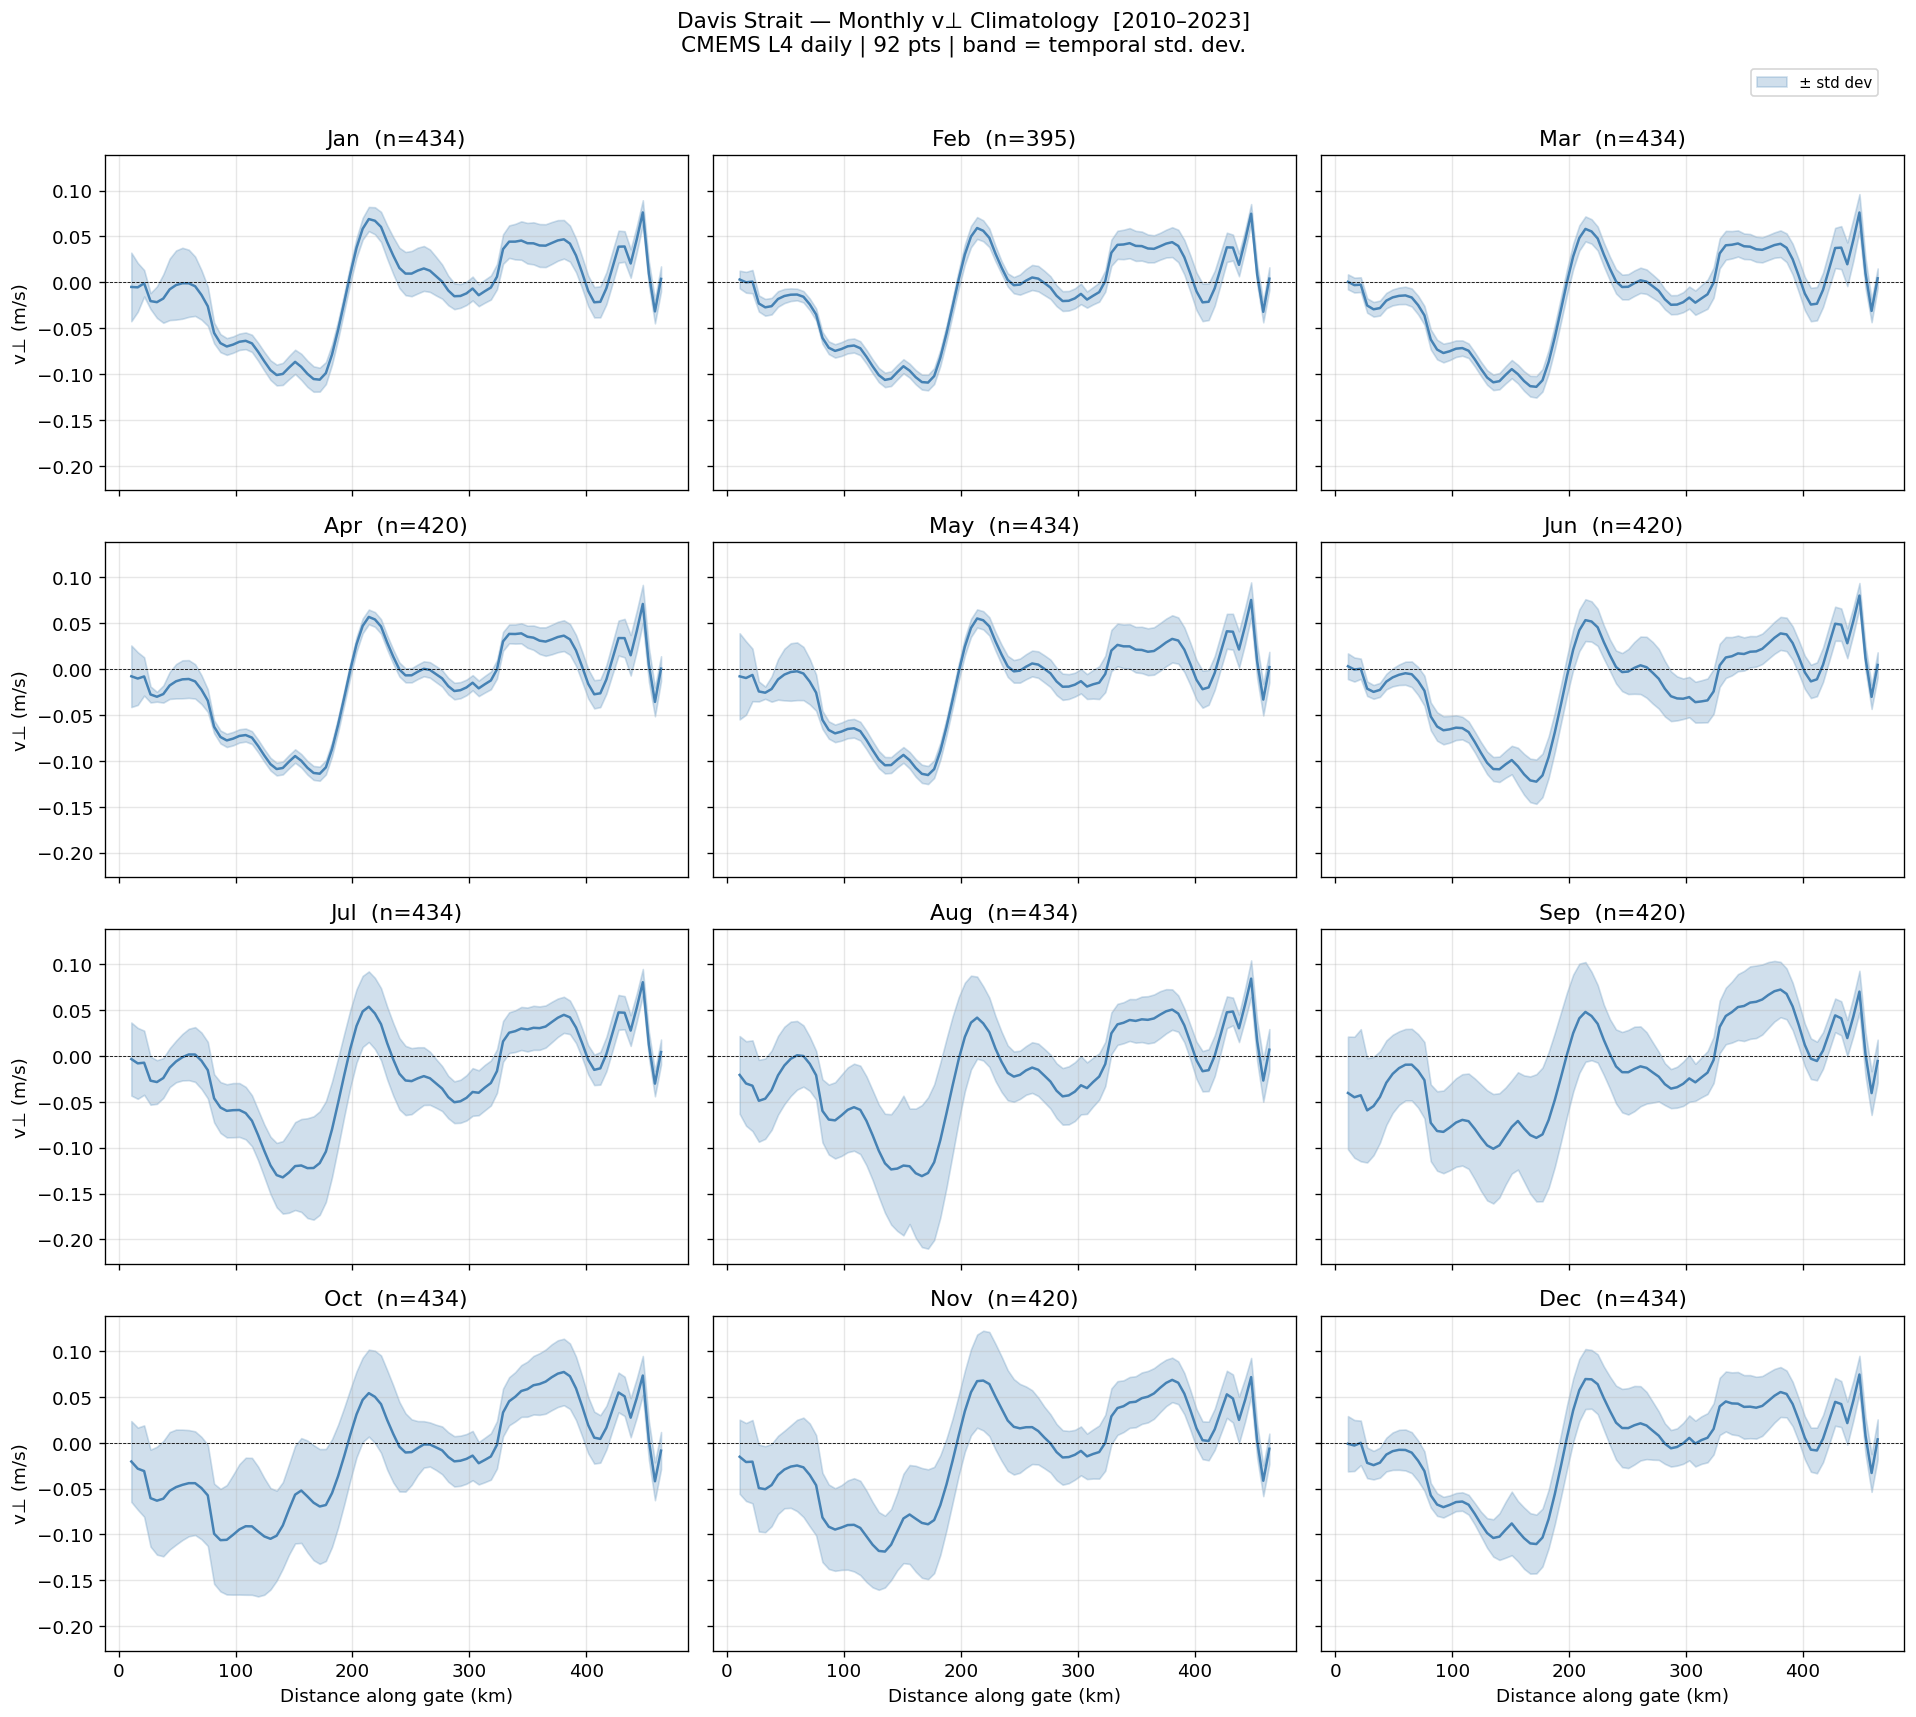

In [24]:
# Perpendicular velocity + formal uncertainty (local per-point method)
v_perp   = perpendicular_velocity(ds)                 # (point, time)
sigma_vp = perpendicular_velocity_uncertainty(ds)     # (point, time)

profiles = monthly_along_gate_profile(v_perp, time, x_km, sigma=sigma_vp)

plot_monthly_grid(
    x_km=x_km,
    profiles=profiles,
    y_label='v⊥ (m/s)',
    color='steelblue',
    title=(
        f'{gate_name} — Monthly v⊥ Climatology  [{DATE_START[:4]}–{DATE_END[:4]}]<br>'
        f'<sup>Local per-point projection | CMEMS L4 daily | {ds.sizes["point"]} pts | band = temporal std. dev.</sup>'
    ),
    band_label='± std dev',
    zero_line=True,
)

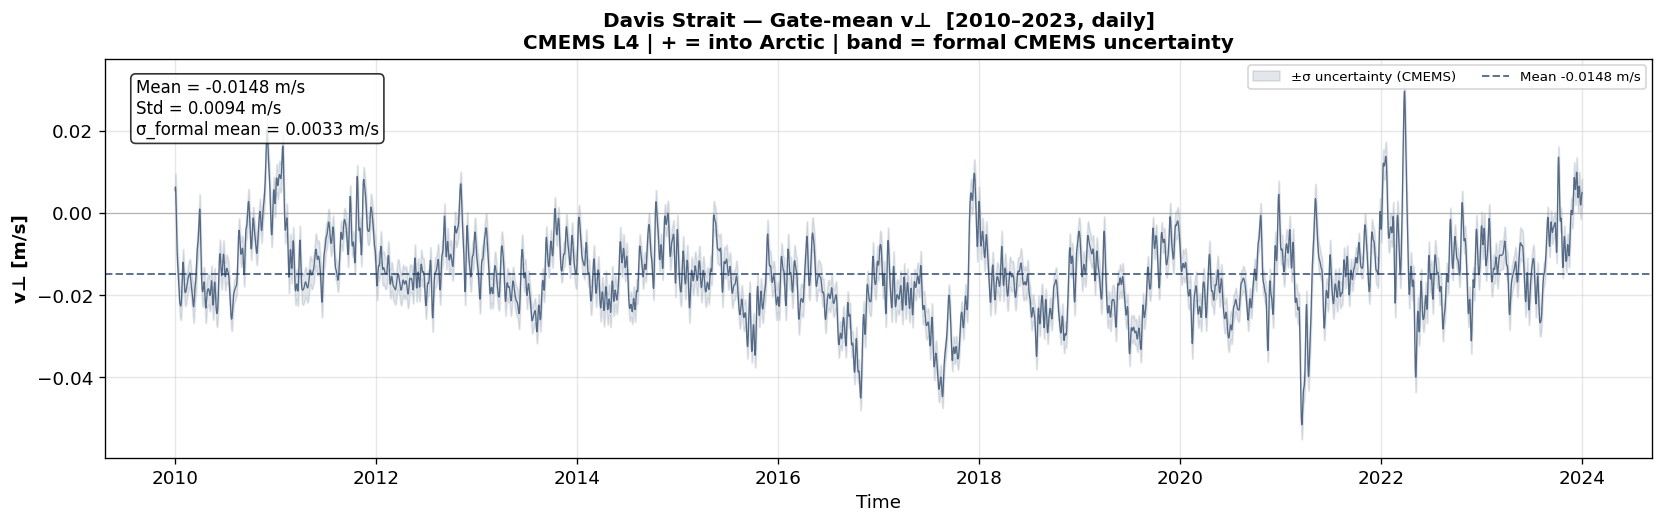

In [31]:
# ── 1b. v⊥ mean timeseries ──
vp_mean_ts = np.nanmean(v_perp, axis=0)  # (time,) m/s

# σ_mean(t) = √( Σᵢ σᵢ(t)² ) / N_valid(t)
N_valid = np.sum(~np.isnan(sigma_vp), axis=0).astype(float)
N_valid[N_valid == 0] = np.nan
sig_vp_mean = np.sqrt(np.nansum(sigma_vp**2, axis=0)) / N_valid

col_vp = '#1E3A5F'
fig = go.Figure()

valid = np.isfinite(vp_mean_ts)
fig.add_trace(go.Scatter(
    x=time[valid], y=vp_mean_ts[valid], mode='lines',
    line=dict(color=col_vp, width=1.5), name='Gate-mean v⊥'
))

valid_band = np.isfinite(vp_mean_ts) & np.isfinite(sig_vp_mean)
if np.any(valid_band):
    x_band = np.concatenate([time[valid_band], time[valid_band][::-1]])
    y_band = np.concatenate([
        (vp_mean_ts[valid_band] - sig_vp_mean[valid_band]),
        (vp_mean_ts[valid_band] + sig_vp_mean[valid_band])[::-1],
    ])
    fig.add_trace(go.Scatter(
        x=x_band, y=y_band, fill='toself',
        fillcolor='rgba(30,58,95,0.15)', line=dict(color='rgba(0,0,0,0)'),
        name='±σ uncertainty (CMEMS)', hoverinfo='skip'
    ))

mu_vp = float(np.nanmean(vp_mean_ts))
fig.add_hline(y=mu_vp, line=dict(color=col_vp, width=1.2, dash='dash'))
fig.add_hline(y=0.0, line=dict(color='gray', width=1, dash='dot'))

fig.add_annotation(
    xref='paper', yref='paper', x=0.01, y=0.98, showarrow=False,
    align='left',
    text=(
        f'Mean = {mu_vp:+.4f} m/s<br>'
        f'Std = {np.nanstd(vp_mean_ts):.4f} m/s<br>'
        f'σ_formal mean = {np.nanmean(sig_vp_mean):.4f} m/s'
    ),
    bgcolor='rgba(255,255,255,0.85)'
)

fig.update_layout(
    title=(
        f'{gate_name} — Gate-mean v⊥  [{DATE_START[:4]}–{DATE_END[:4]}, daily]<br>'
        f'<sup>Local per-point projection | + = into Arctic side</sup>'
    ),
    xaxis_title='Time',
    yaxis_title='v⊥ [m/s]',
    template='plotly_white',
    height=420,
)
fig.show()

In [36]:
# ═══════════════════════════════════════════════════════════════════
# SPATIAL MAPPING: Gate + local normals + mean velocity vectors
# ═══════════════════════════════════════════════════════════════════
lon = ds['longitude'].values.astype(float)
lat = ds['latitude'].values.astype(float)

u_loc, v_loc = local_into_arctic_unit_vectors(ds)
u_mean = np.nanmean(ds['ugos'].values, axis=1)
v_mean = np.nanmean(ds['vgos'].values, axis=1)
vp_mean = np.nanmean(v_perp, axis=1)

n_pts = len(lon)
step = max(1, n_pts // 120)
idx = np.arange(0, n_pts, step)

lon_s = lon[idx]
lat_s = lat[idx]

span_lon = float(np.nanmax(lon) - np.nanmin(lon)) if n_pts > 1 else 1.0
span_lat = float(np.nanmax(lat) - np.nanmin(lat)) if n_pts > 1 else 1.0
span = max(span_lon, span_lat, 1.0)

# Plot scales in degrees (visual only)
norm_scale = 0.02 * span
vel_scale = 0.03 * span

vel_mag_ref = float(np.nanpercentile(np.hypot(u_mean[idx], v_mean[idx]), 95)) if np.any(np.isfinite(u_mean[idx])) else 1.0
if not np.isfinite(vel_mag_ref) or vel_mag_ref <= 1e-12:
    vel_mag_ref = 1.0

u_norm_plot = u_loc[idx] * norm_scale
v_norm_plot = v_loc[idx] * norm_scale
u_vel_plot = (u_mean[idx] / vel_mag_ref) * vel_scale
v_vel_plot = (v_mean[idx] / vel_mag_ref) * vel_scale


def _segments(x0, y0, du, dv):
    xs, ys = [], []
    for x, y, u, v in zip(x0, y0, du, dv):
        if not (np.isfinite(x) and np.isfinite(y) and np.isfinite(u) and np.isfinite(v)):
            continue
        xs.extend([x, x + u, None])
        ys.extend([y, y + v, None])
    return xs, ys

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=lon, y=lat, mode='lines',
    line=dict(color='#E74C3C', width=2),
    name=f'Gate line ({n_pts} pts)'
))

fig.add_trace(go.Scatter(
    x=lon, y=lat, mode='markers',
    marker=dict(
        size=6,
        color=vp_mean,
        colorscale='RdBu',
        cmin=-np.nanpercentile(np.abs(vp_mean), 95),
        cmax=np.nanpercentile(np.abs(vp_mean), 95),
        colorbar=dict(title='mean v⊥ (m/s)'),
        line=dict(color='white', width=0.4),
    ),
    name='Gate points colored by mean v⊥'
))

x_norm, y_norm = _segments(lon_s, lat_s, u_norm_plot, v_norm_plot)
fig.add_trace(go.Scatter(
    x=x_norm, y=y_norm, mode='lines',
    line=dict(color='black', width=1.5),
    name='Local normal → Arctic side'
))

x_vel, y_vel = _segments(lon_s, lat_s, u_vel_plot, v_vel_plot)
fig.add_trace(go.Scatter(
    x=x_vel, y=y_vel, mode='lines',
    line=dict(color='#2E8B57', width=1.5),
    name='Mean velocity vector (ugos, vgos)'
))

fig.update_layout(
    title=(
        f'{gate_name} — Spatial mapping of local projection vectors<br>'
        f'<sup>Black: local into-Arctic normals | Green: mean CMEMS velocity vectors</sup>'
    ),
    xaxis_title='Longitude (°E)',
    yaxis_title='Latitude (°N)',
    template='plotly_white',
    height=620,
    yaxis=dict(scaleanchor='x', scaleratio=1),
)
fig.show()

print('Vector mapping ready: sign is computed from local normal at each gate point.')

1. θ FROM NetCDF (used for all computations)
   θ values:  min=0.00°  max=0.00°
   ⚠️  θ = 0 → v_perp = vgos ONLY (ignoring ugos completely!)

2. GATE GEOMETRY
   First point (W):  (-64.403°E, 67.684°N)
   Last  point (E):  (-52.980°E, 68.138°N)
   Midpoint:         (-58.697°E, 68.034°N)
   Δlon = 11.423°,  Δlat = 0.454°
   Tangent bearing:  83.9° (gate runs nearly W→E)
   Gate is almost zonal, so cross-gate direction ≈ north-south

3. GEOMETRIC vs STATIC INTO-ARCTIC VECTOR
   Static  (dict):    (+0.0000, +1.0000)  → θ = +0.00°
   Geometric (auto):  (-0.1056, +0.9944)  → θ = -6.06°
   Angular difference: 6.1°
   sin(0°) = 0.0000,  sin(-6.1°) = -0.1056
   cos(0°) = 1.0000,  cos(-6.1°) = 0.9944

4. IMPACT ON VOLUME TRANSPORT
   VT (θ =  0.0°):  mean = -0.883 Sv
   VT (θ = -6.1°):  mean = -1.294 Sv
   Change:  -46.6%  (-0.411 Sv)

   Breakdown of θ=−6.1° VT:
     ugos·sin(θ) contribution: -0.416 Sv
     vgos·cos(θ) contribution: -0.878 Sv
   ⟹  ugos·sin(−6.1°) adds -0.416 Sv (32% of total

---
## 2 · Volume Transport
`VT(t) = Σ_i v⊥(i,t) · min(depth(i), cap) · dx(i)` in Sv (10⁶ m³/s), with local per-point `v⊥`.

- **4×3 profile**: per-point VT along gate, band = temporal std. dev.
- **Timeseries**: integrated VT, band = formal CMEMS σ

/Users/nicolocaron/Documents/GitHub/ARCFRESH-DTU-NICO-and-AMALIE/.venv/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


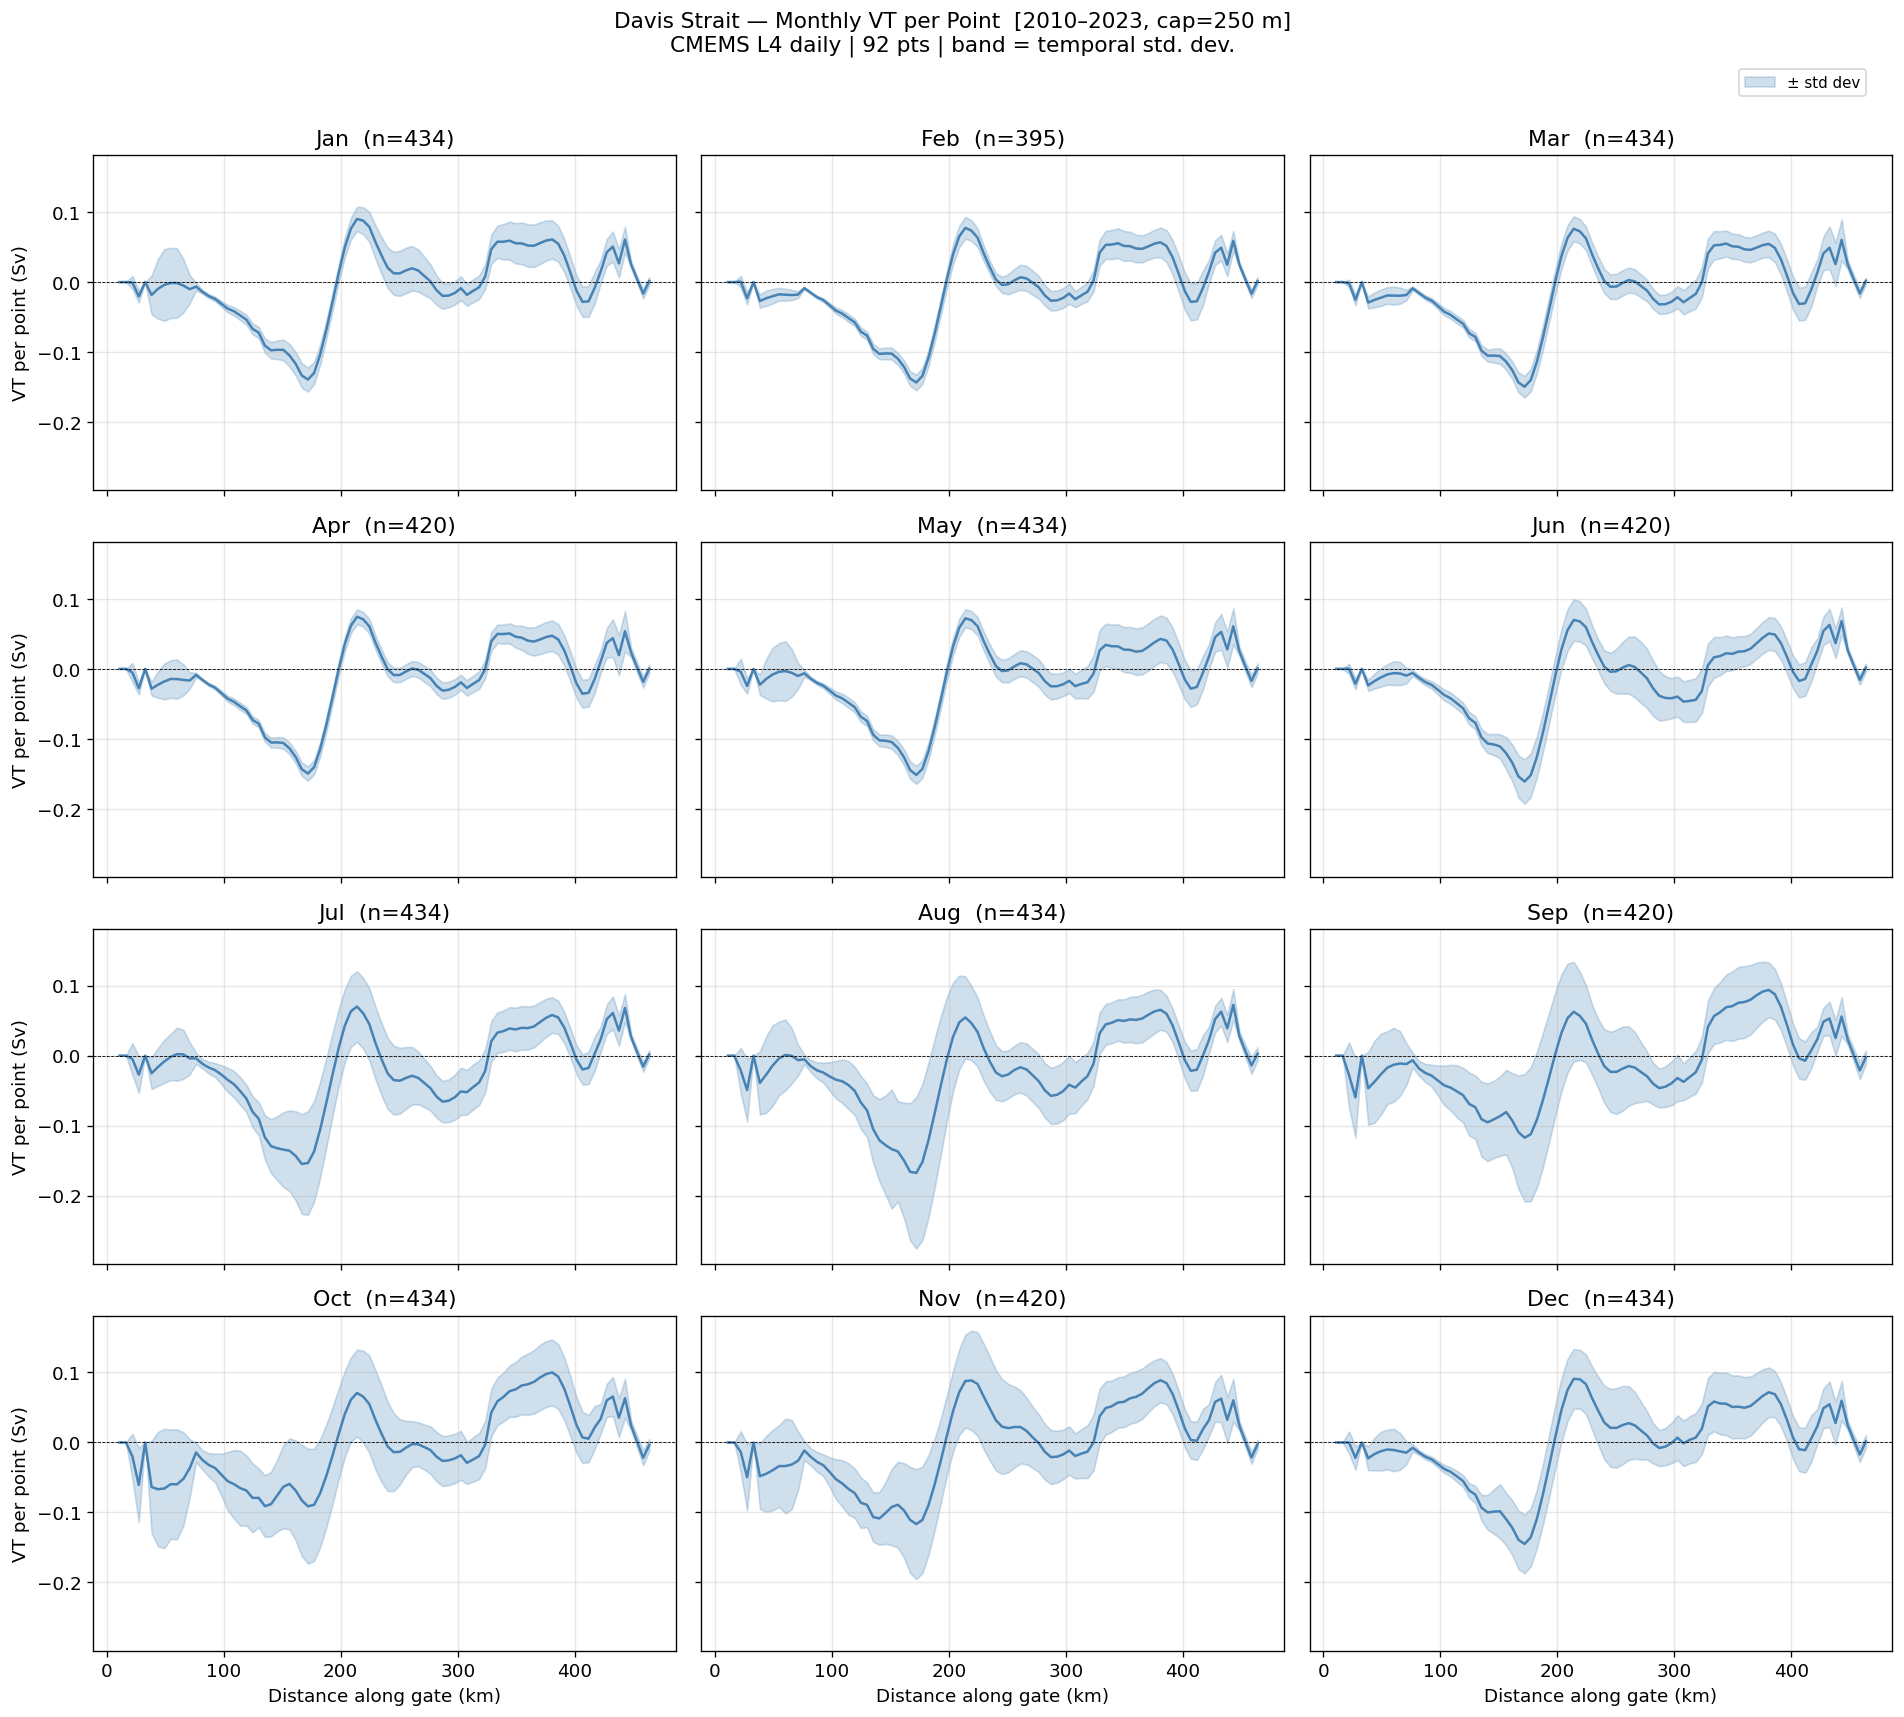

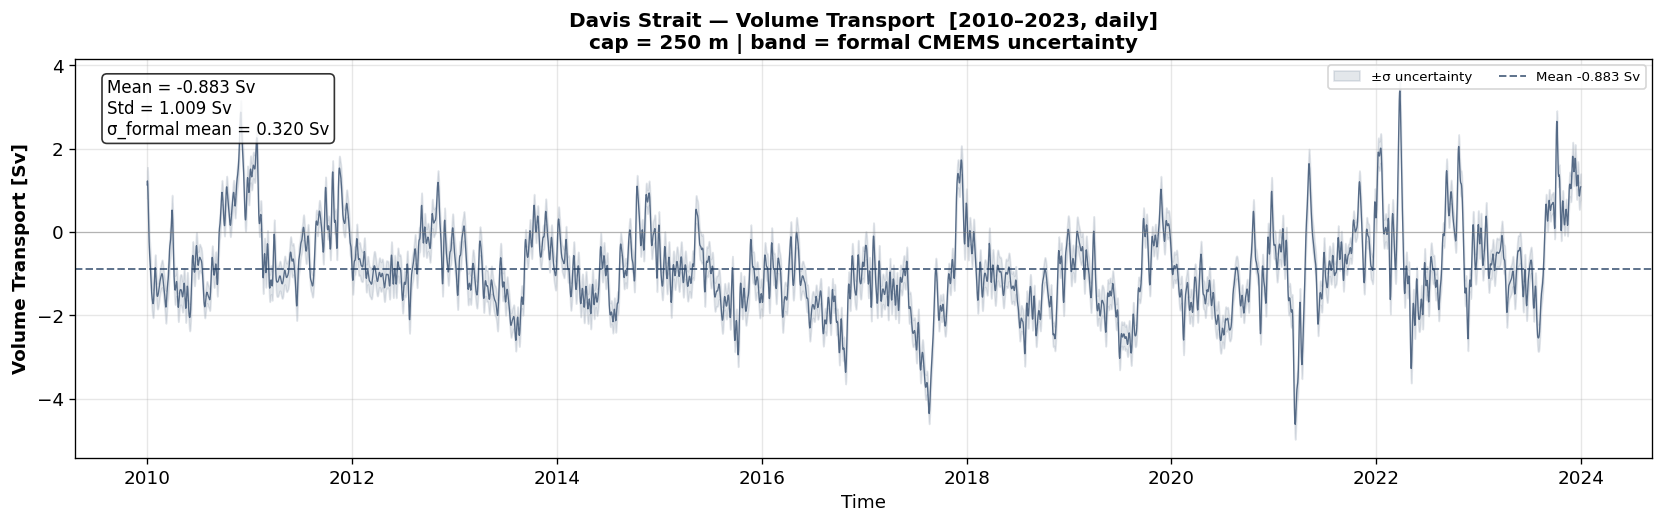

In [26]:
# ── 2a. Volume Transport: 4×3 monthly along-gate profile ──
vt_pp       = volume_transport_per_point(ds, depth_cap=CAP)              # (point, time) Sv
sigma_vt_pp = volume_transport_per_point_uncertainty(ds, depth_cap=CAP)  # (point, time) Sv

vt_profiles = monthly_along_gate_profile(vt_pp, time, x_km, sigma=sigma_vt_pp)

plot_monthly_grid(
    x_km=x_km,
    profiles=vt_profiles,
    y_label='VT per point (Sv)',
    color='steelblue',
    title=(
        f'{gate_name} — Monthly VT per Point  [{DATE_START[:4]}–{DATE_END[:4]}, cap={CAP} m]<br>'
        f'<sup>Local per-point projection | CMEMS L4 daily | band = temporal std. dev.</sup>'
    ),
    band_label='± std dev',
    zero_line=True,
)

# ── 2b. Volume Transport: time series ──
vt_sv, t = volume_transport(ds, depth_cap=CAP)
sigma_vt = volume_transport_uncertainty(ds, depth_cap=CAP)

col_vt = '#1E3A5F'
fig = go.Figure()
valid = np.isfinite(vt_sv)
fig.add_trace(go.Scatter(x=t[valid], y=vt_sv[valid], mode='lines', line=dict(color=col_vt, width=1.5), name='VT'))

valid_band = np.isfinite(vt_sv) & np.isfinite(sigma_vt)
if np.any(valid_band):
    x_band = np.concatenate([t[valid_band], t[valid_band][::-1]])
    y_band = np.concatenate([(vt_sv[valid_band] - sigma_vt[valid_band]), (vt_sv[valid_band] + sigma_vt[valid_band])[::-1]])
    fig.add_trace(go.Scatter(x=x_band, y=y_band, fill='toself', fillcolor='rgba(30,58,95,0.15)',
                             line=dict(color='rgba(0,0,0,0)'), name='±σ uncertainty', hoverinfo='skip'))

mean_vt = float(np.nanmean(vt_sv))
fig.add_hline(y=mean_vt, line=dict(color=col_vt, width=1.2, dash='dash'))
fig.add_hline(y=0.0, line=dict(color='gray', width=1, dash='dot'))

fig.add_annotation(
    xref='paper', yref='paper', x=0.01, y=0.98, showarrow=False, align='left',
    text=(
        f'Mean = {mean_vt:+.3f} Sv<br>'
        f'Std = {np.nanstd(vt_sv):.3f} Sv<br>'
        f'σ_formal mean = {np.nanmean(sigma_vt):.3f} Sv'
    ),
    bgcolor='rgba(255,255,255,0.85)'
)

fig.update_layout(
    title=(
        f'{gate_name} — Volume Transport  [{DATE_START[:4]}–{DATE_END[:4]}, daily]<br>'
        f'<sup>cap = {CAP} m | local per-point projection</sup>'
    ),
    xaxis_title='Time',
    yaxis_title='Volume Transport [Sv]',
    template='plotly_white',
    height=420,
)
fig.show()

---
## 3 · Surface Salinity Profile (CCI + ISAS surface)
- `sss`: ESA CCI SSS v5.5 monthly (day 1+15 aggregated) mapped to daily axis
- `psal_isas_surface`: ISAS PSAL first layer climatology mapped to daily axis

Plots:
1. **4×3 profile**: monthly climatology, band = temporal std. dev.
2. **Timeseries**: gate-mean salinity, band = spatial σ

/Users/nicolocaron/Documents/GitHub/ARCFRESH-DTU-NICO-and-AMALIE/.venv/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


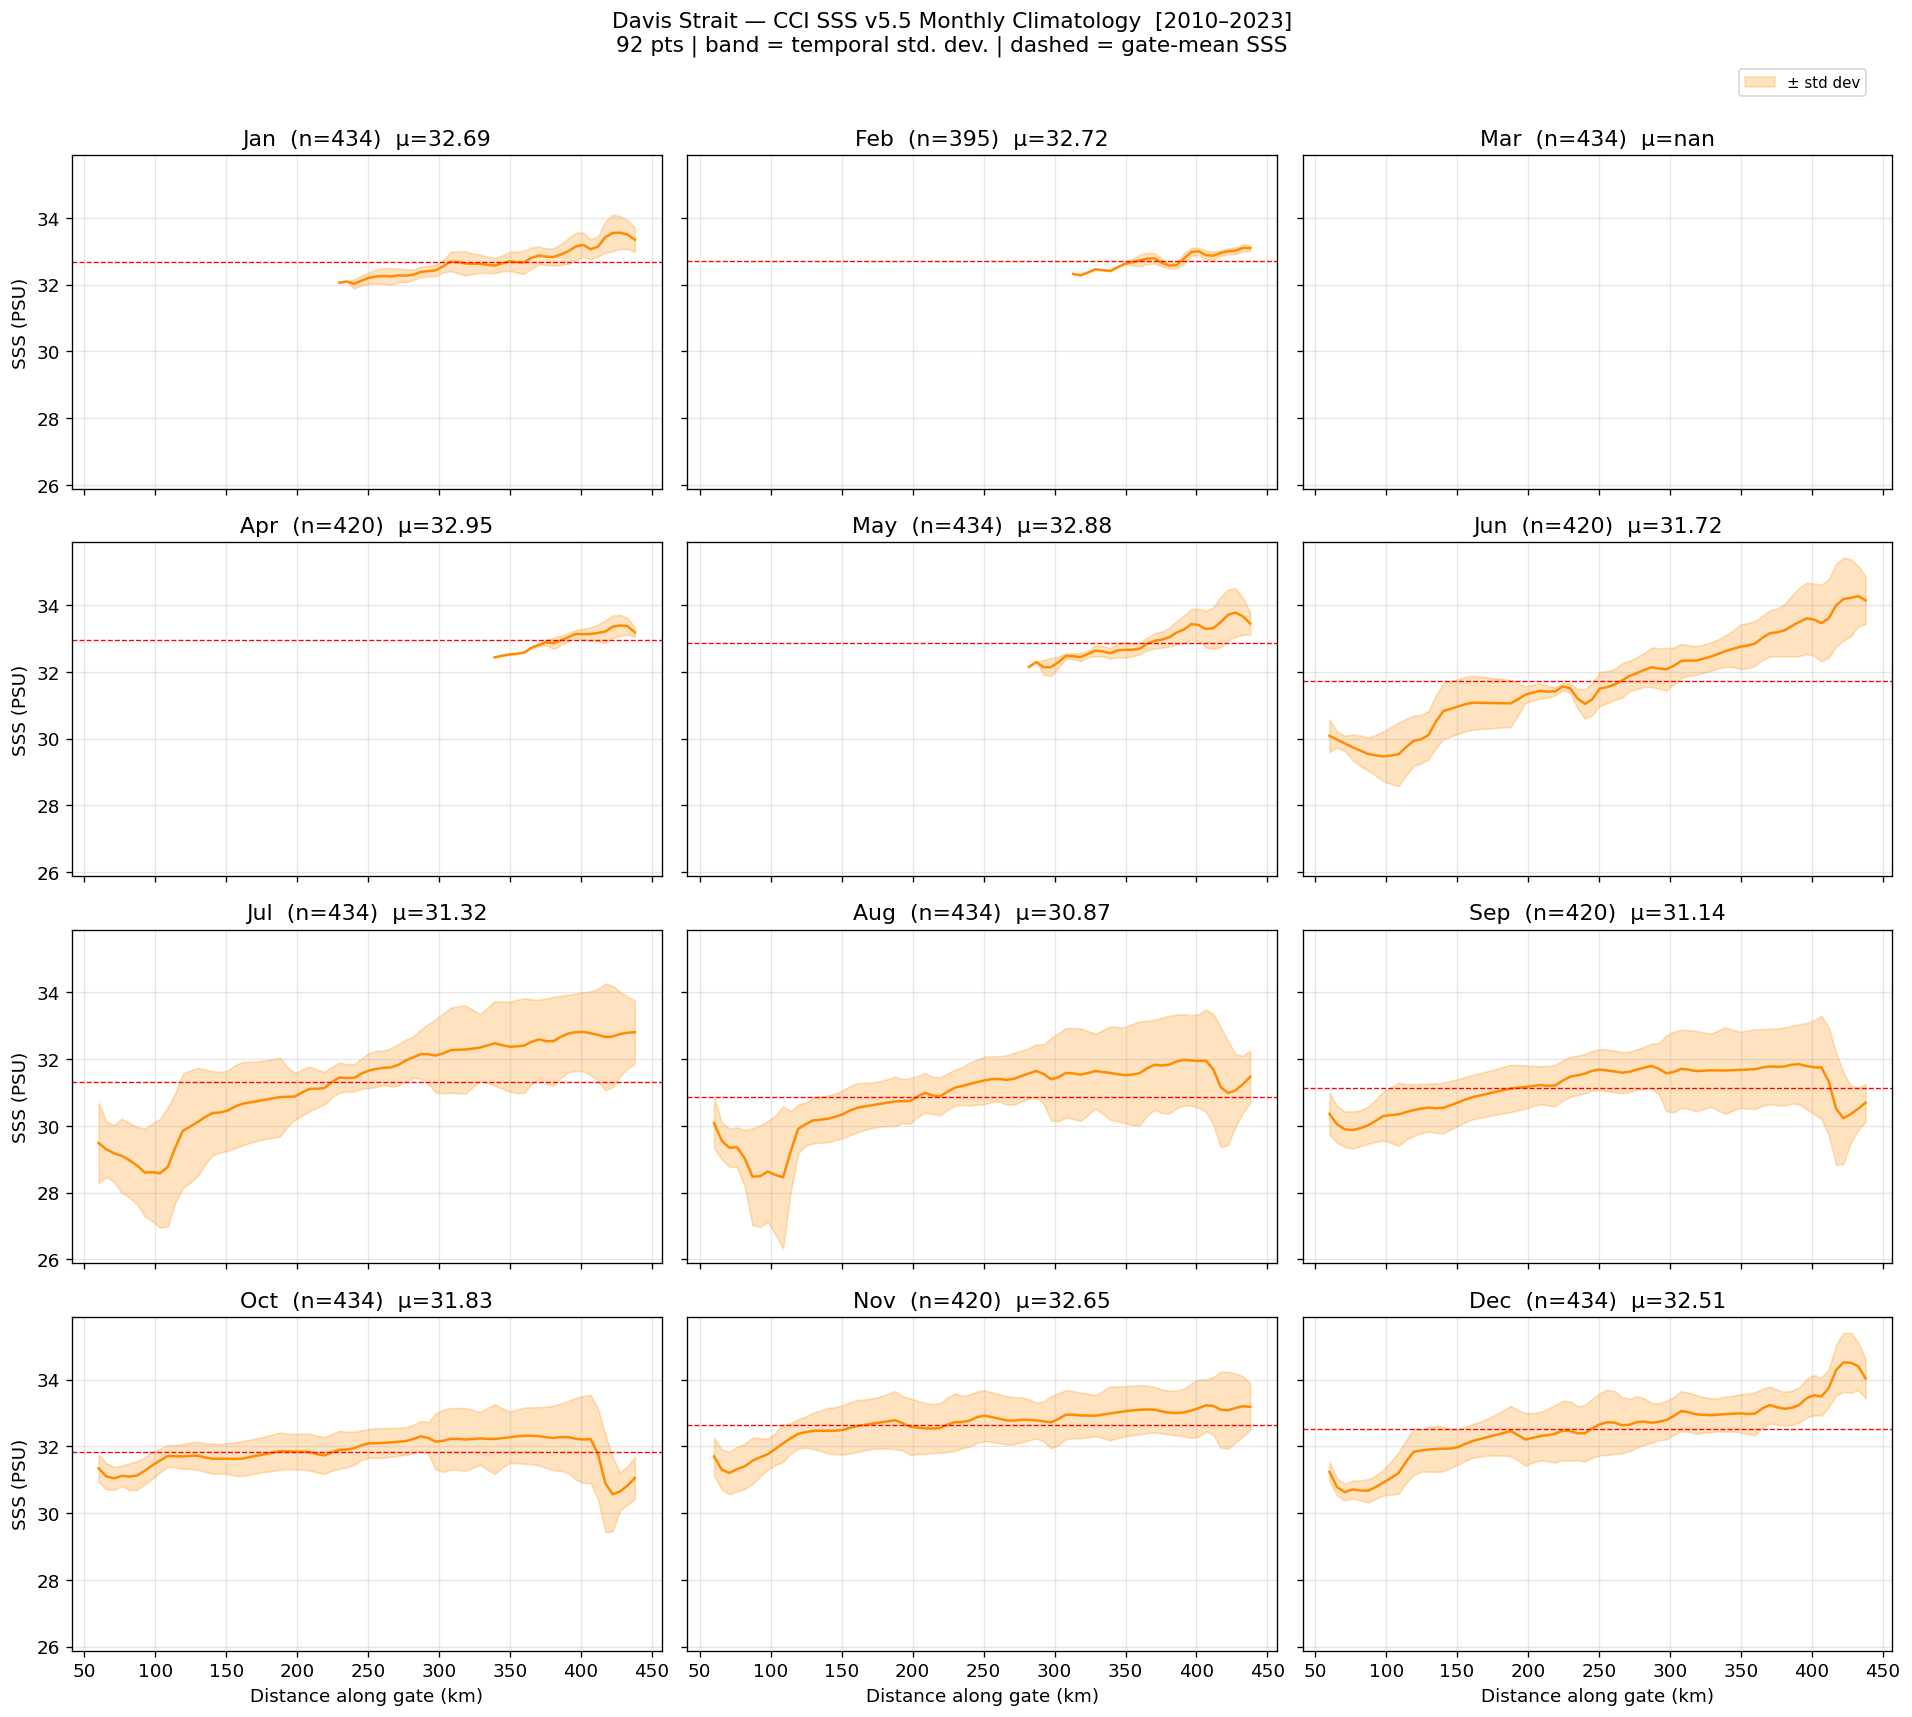

In [27]:
sources = []
if has_cci and 'sss' in ds:
    sources.append(('sss', 'CCI SSS v5.5', 'darkorange'))
if has_isas and 'psal_isas_surface' in ds:
    sources.append(('psal_isas_surface', 'ISAS PSAL surface (z0 climatology)', 'seagreen'))

if not sources:
    print('⚠️  No salinity source available — skip salinity profile.')
else:
    for var_name, label, color in sources:
        sal = ds[var_name].values
        if not np.isfinite(sal).any():
            print(f'⚠️  {label}: all NaN in selected period — skip profile.')
            continue

        sal_profiles = monthly_along_gate_profile(sal, time, x_km)
        plot_monthly_grid(
            x_km=x_km,
            profiles=sal_profiles,
            y_label='Salinity (PSU)',
            color=color,
            title=(
                f'{gate_name} — {label} Monthly Climatology  [{DATE_START[:4]}–{DATE_END[:4]}]<br>'
                f'<sup>{ds.sizes["point"]} pts | band = temporal std. dev.</sup>'
            ),
            band_label='± std dev',
            zero_line=False,
        )

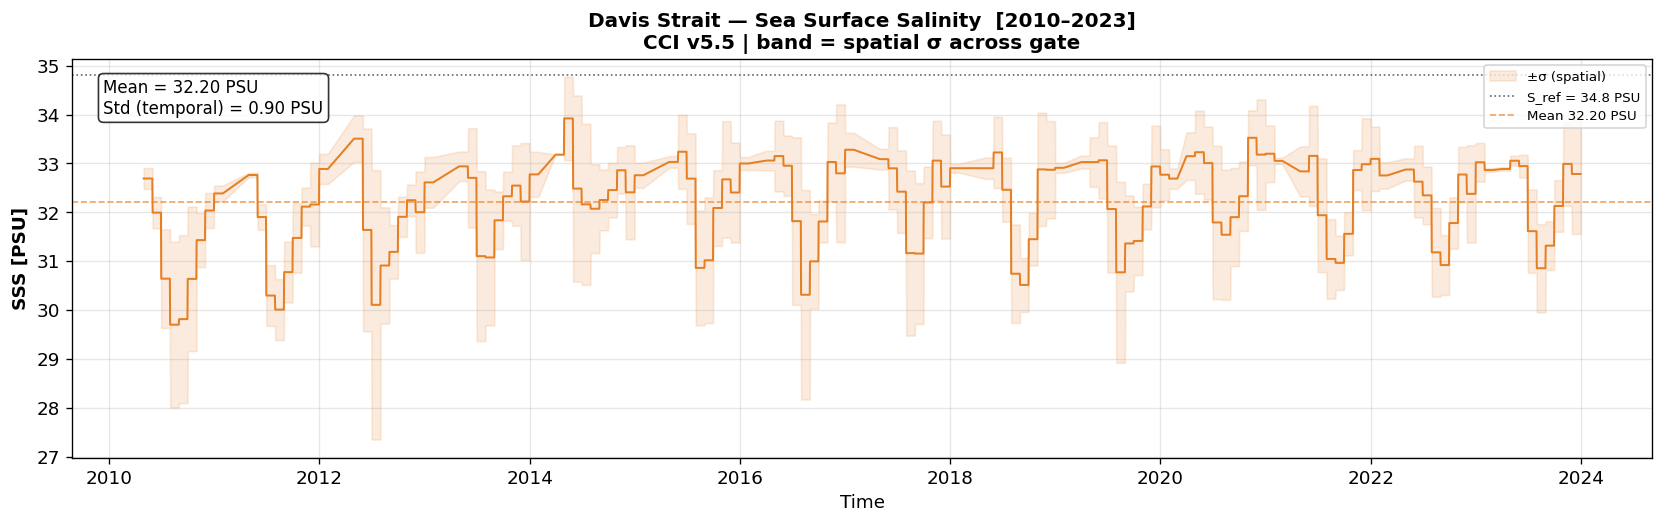

In [28]:
# ── 3b. Salinity mean timeseries ──
sources = []
if has_cci and 'sss' in ds:
    sources.append(('sss', 'CCI SSS v5.5', '#E67E22'))
if has_isas and 'psal_isas_surface' in ds:
    sources.append(('psal_isas_surface', 'ISAS PSAL surface (z0 climatology)', '#2E8B57'))

if not sources:
    print('⚠️  No salinity source available — skip salinity timeseries.')
else:
    for var_name, label, color in sources:
        sal = ds[var_name].values
        if not np.isfinite(sal).any():
            print(f'⚠️  {label}: all NaN in selected period — skip timeseries.')
            continue

        sal_mean_ts = np.nanmean(sal, axis=0)
        sal_std_ts = np.nanstd(sal, axis=0)
        valid = np.isfinite(sal_mean_ts)

        fig = go.Figure()
        fig.add_trace(go.Scatter(
            x=time[valid], y=sal_mean_ts[valid], mode='lines',
            line=dict(color=color, width=1.5), name=f'{label} mean'
        ))

        valid_band = np.isfinite(sal_mean_ts) & np.isfinite(sal_std_ts)
        if np.any(valid_band):
            x_band = np.concatenate([time[valid_band], time[valid_band][::-1]])
            y_band = np.concatenate([
                (sal_mean_ts[valid_band] - sal_std_ts[valid_band]),
                (sal_mean_ts[valid_band] + sal_std_ts[valid_band])[::-1],
            ])
            fig.add_trace(go.Scatter(
                x=x_band, y=y_band, fill='toself',
                fillcolor='rgba(230,126,34,0.15)' if var_name == 'sss' else 'rgba(46,139,87,0.15)',
                line=dict(color='rgba(0,0,0,0)'), name='±σ (spatial)', hoverinfo='skip'
            ))

        mu = float(np.nanmean(sal_mean_ts))
        fig.add_hline(y=mu, line=dict(color=color, width=1.2, dash='dash'))
        fig.add_hline(y=S_REF, line=dict(color='black', width=1, dash='dot'))

        fig.add_annotation(
            xref='paper', yref='paper', x=0.01, y=0.98, showarrow=False, align='left',
            text=(
                f'Mean = {mu:.2f} PSU<br>'
                f'Temporal std = {np.nanstd(sal_mean_ts[valid]):.2f} PSU'
            ),
            bgcolor='rgba(255,255,255,0.85)'
        )

        fig.update_layout(
            title=(
                f'{gate_name} — {label}  [{DATE_START[:4]}–{DATE_END[:4]}]<br>'
                f'<sup>band = spatial σ across gate points | dotted line: S_ref={S_REF}</sup>'
            ),
            xaxis_title='Time',
            yaxis_title='Salinity [PSU]',
            template='plotly_white',
            height=420,
        )
        fig.show()

---
## 4 · Freshwater Transport
`FW(t) = Σ_i v⊥(i,t) · (1 − SSS(i,t)/S_ref) · min(depth(i), cap) · dx(i)` in mSv.

- Uses local per-point `v⊥`
- Uses `sss` (CCI-based field in gate NetCDF)

Plots:
1. **4×3 profile**: per-point FW along gate, band = temporal std. dev.
2. **Timeseries**: integrated FW, band = formal velocity σ propagation

/Users/nicolocaron/Documents/GitHub/ARCFRESH-DTU-NICO-and-AMALIE/.venv/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


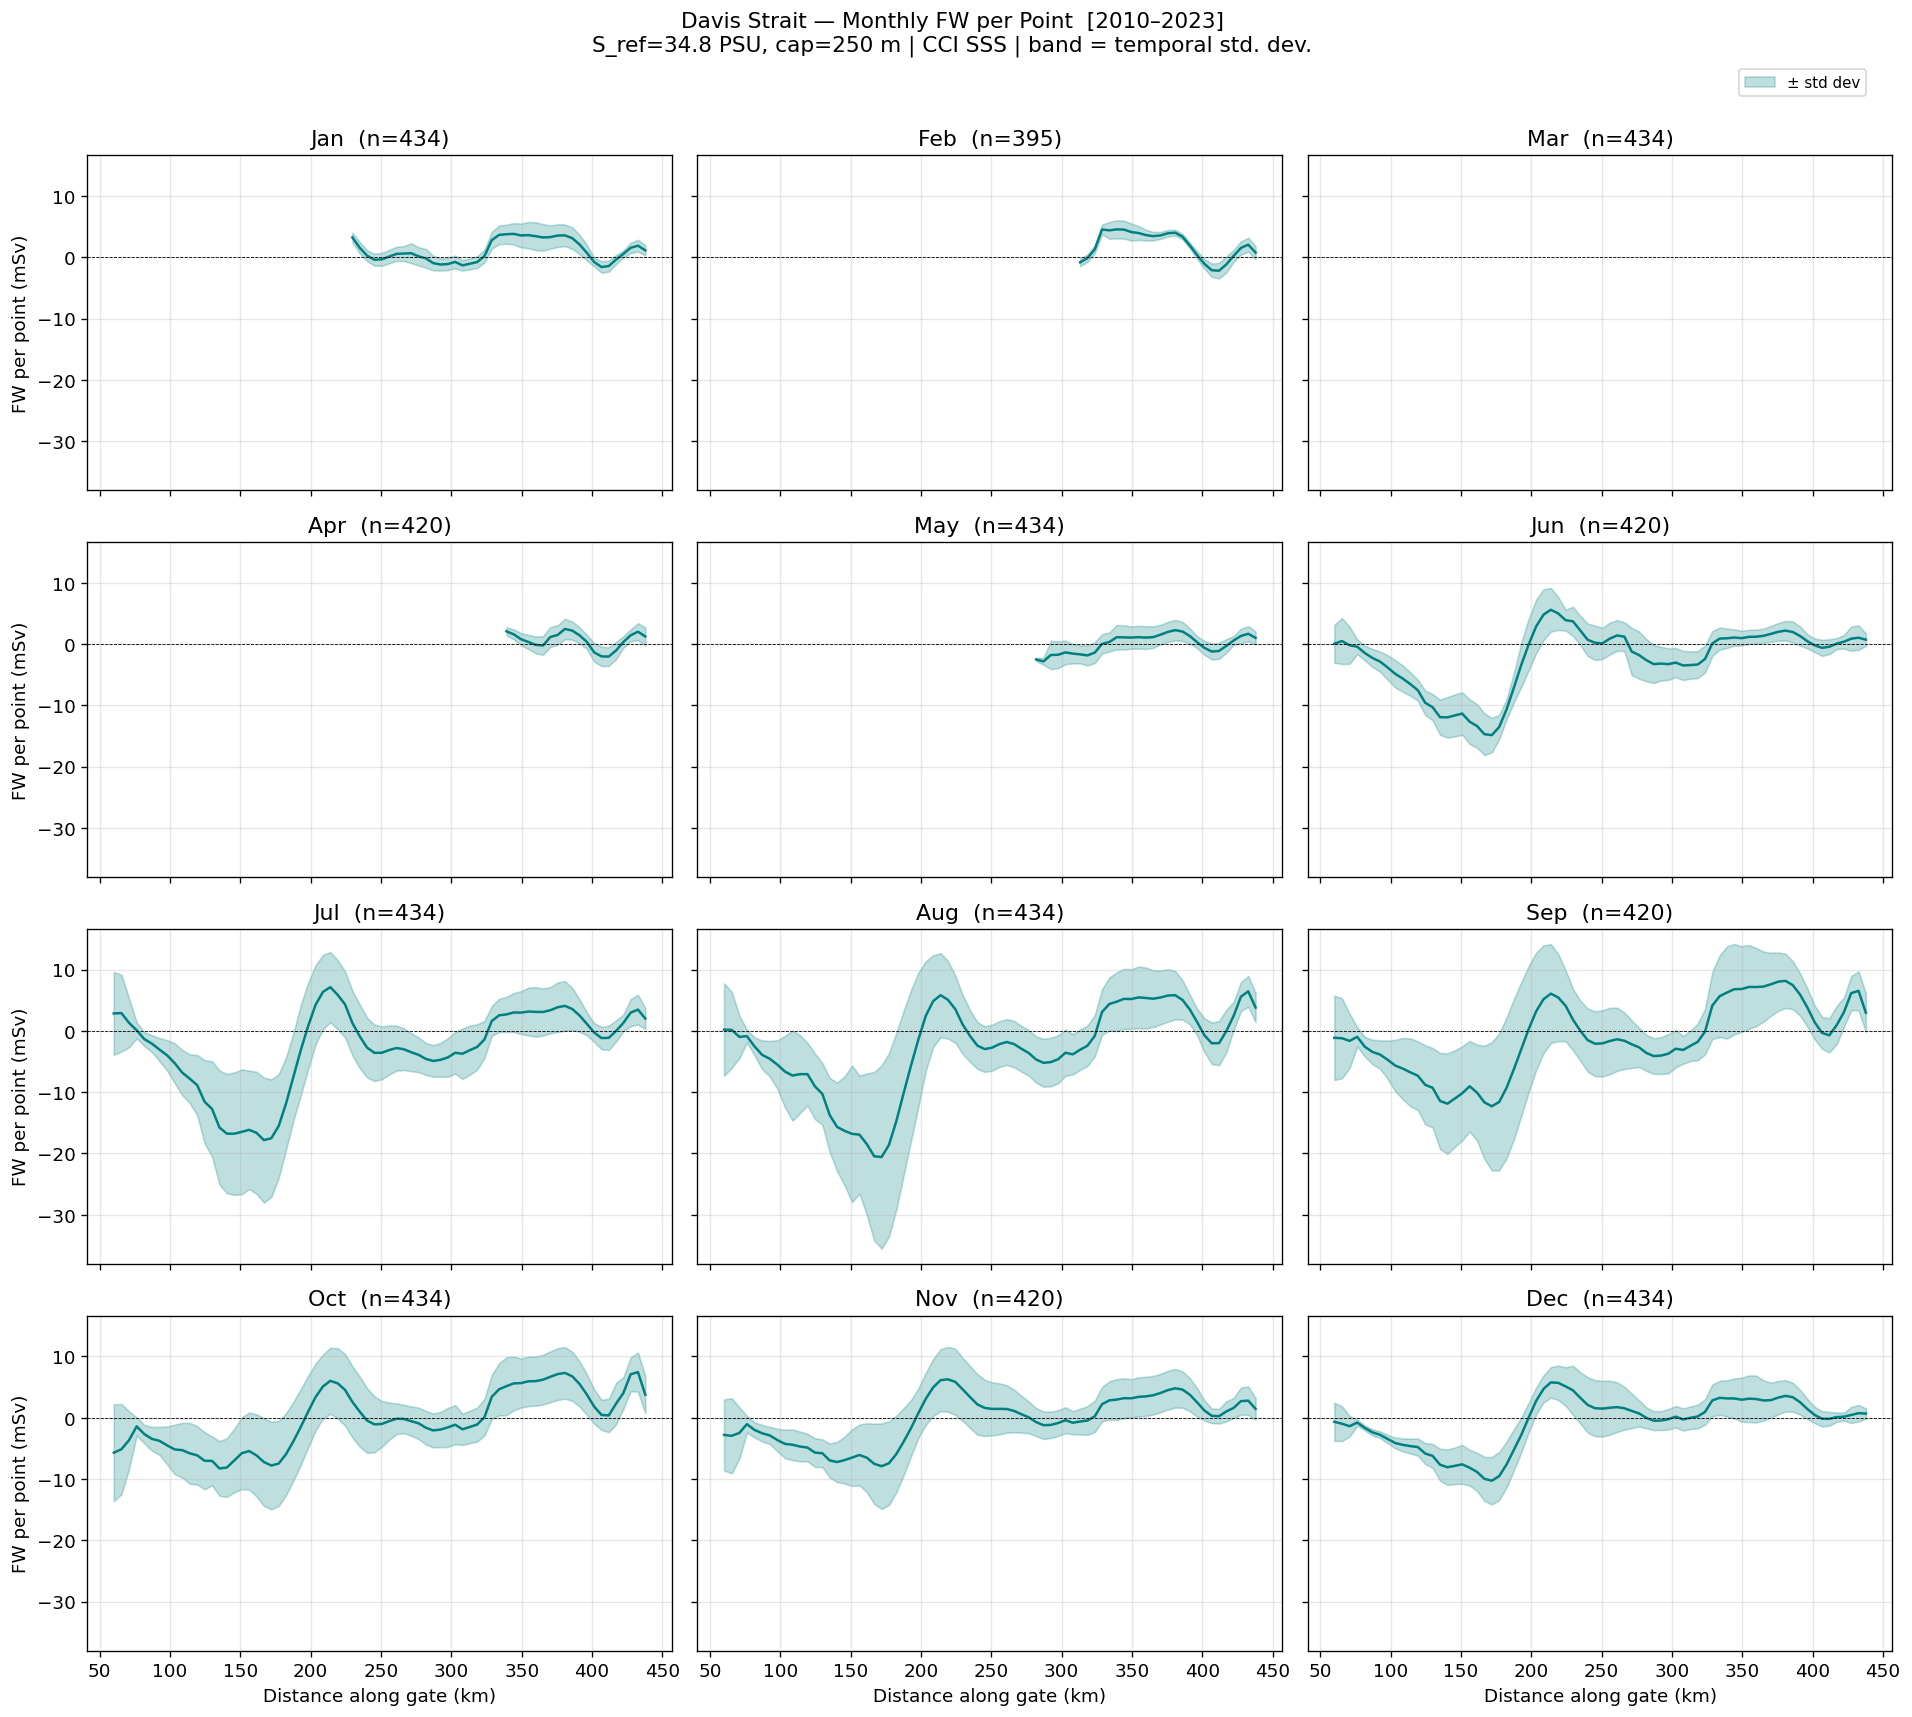

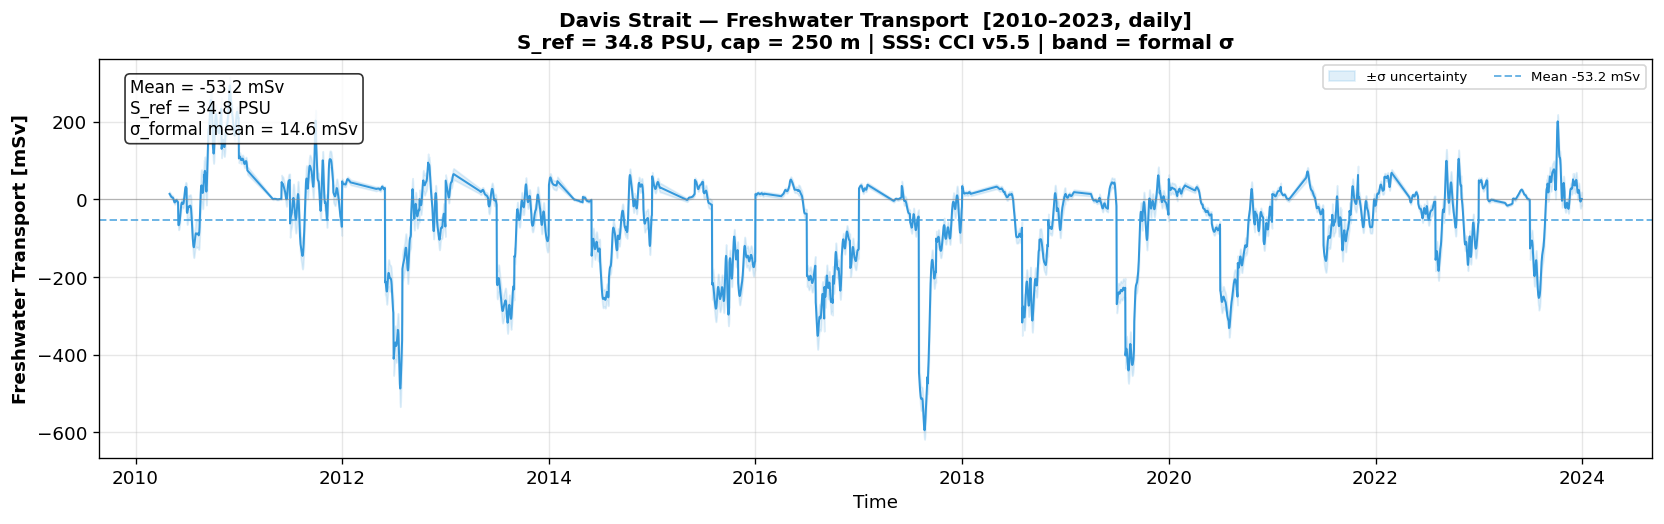

In [29]:
if not has_sss:
    print('⚠️  No finite CCI SSS data for this gate/period — skip freshwater transport.')
else:
    fw_pp = freshwater_transport_per_point(ds, depth_cap=CAP, s_ref=S_REF)              # m³/s
    sigma_fw_pp = freshwater_transport_per_point_uncertainty(ds, depth_cap=CAP, s_ref=S_REF)
    fw_pp_msv = fw_pp / 1e3
    sigma_fw_pp_msv = sigma_fw_pp / 1e3

    fw_profiles = monthly_along_gate_profile(fw_pp_msv, time, x_km, sigma=sigma_fw_pp_msv)

    plot_monthly_grid(
        x_km=x_km,
        profiles=fw_profiles,
        y_label='FW per point (mSv)',
        color='teal',
        title=(
            f'{gate_name} — Monthly FW per Point  [{DATE_START[:4]}–{DATE_END[:4]}]<br>'
            f'<sup>S_ref={S_REF} PSU, cap={CAP} m | local per-point projection | band = temporal std. dev.</sup>'
        ),
        band_label='± std dev',
        zero_line=True,
    )

    fw, t_fw = freshwater_transport(ds, depth_cap=CAP, s_ref=S_REF)
    sigma_fw = freshwater_transport_uncertainty(ds, depth_cap=CAP, s_ref=S_REF)
    fw_msv = fw / 1e3
    sigma_fw_msv = sigma_fw / 1e3

    col_fw = '#3498DB'
    fig = go.Figure()
    valid = np.isfinite(fw_msv)
    fig.add_trace(go.Scatter(x=t_fw[valid], y=fw_msv[valid], mode='lines', line=dict(color=col_fw, width=1.5), name='FW'))

    valid_band = np.isfinite(fw_msv) & np.isfinite(sigma_fw_msv)
    if np.any(valid_band):
        x_band = np.concatenate([t_fw[valid_band], t_fw[valid_band][::-1]])
        y_band = np.concatenate([(fw_msv[valid_band] - sigma_fw_msv[valid_band]), (fw_msv[valid_band] + sigma_fw_msv[valid_band])[::-1]])
        fig.add_trace(go.Scatter(x=x_band, y=y_band, fill='toself', fillcolor='rgba(52,152,219,0.15)',
                                 line=dict(color='rgba(0,0,0,0)'), name='±σ uncertainty', hoverinfo='skip'))

    mean_fw = float(np.nanmean(fw_msv))
    fig.add_hline(y=mean_fw, line=dict(color=col_fw, width=1.2, dash='dash'))
    fig.add_hline(y=0.0, line=dict(color='gray', width=1, dash='dot'))

    fig.add_annotation(
        xref='paper', yref='paper', x=0.01, y=0.98, showarrow=False, align='left',
        text=(
            f'Mean = {mean_fw:+.1f} mSv<br>'
            f'σ_formal mean = {np.nanmean(sigma_fw_msv):.1f} mSv'
        ),
        bgcolor='rgba(255,255,255,0.85)'
    )

    fig.update_layout(
        title=(
            f'{gate_name} — Freshwater Transport  [{DATE_START[:4]}–{DATE_END[:4]}, daily]<br>'
            f'<sup>S_ref={S_REF} PSU, cap={CAP} m | local per-point projection</sup>'
        ),
        xaxis_title='Time',
        yaxis_title='Freshwater Transport [mSv]',
        template='plotly_white',
        height=420,
    )
    fig.show()

---
## 5 · Salt Flux
`Salt(t) = Σ_i ρ · (SSS(i,t)/1000) · v⊥(i,t) · min(depth(i), cap) · dx(i)` in Gg/s.

- Uses local per-point `v⊥`
- Uses `sss` (CCI-based field in gate NetCDF)

Plots:
1. **4×3 profile**: per-point salt flux along gate, band = temporal std. dev.
2. **Timeseries**: integrated salt flux, band = formal velocity σ propagation

/Users/nicolocaron/Documents/GitHub/ARCFRESH-DTU-NICO-and-AMALIE/.venv/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


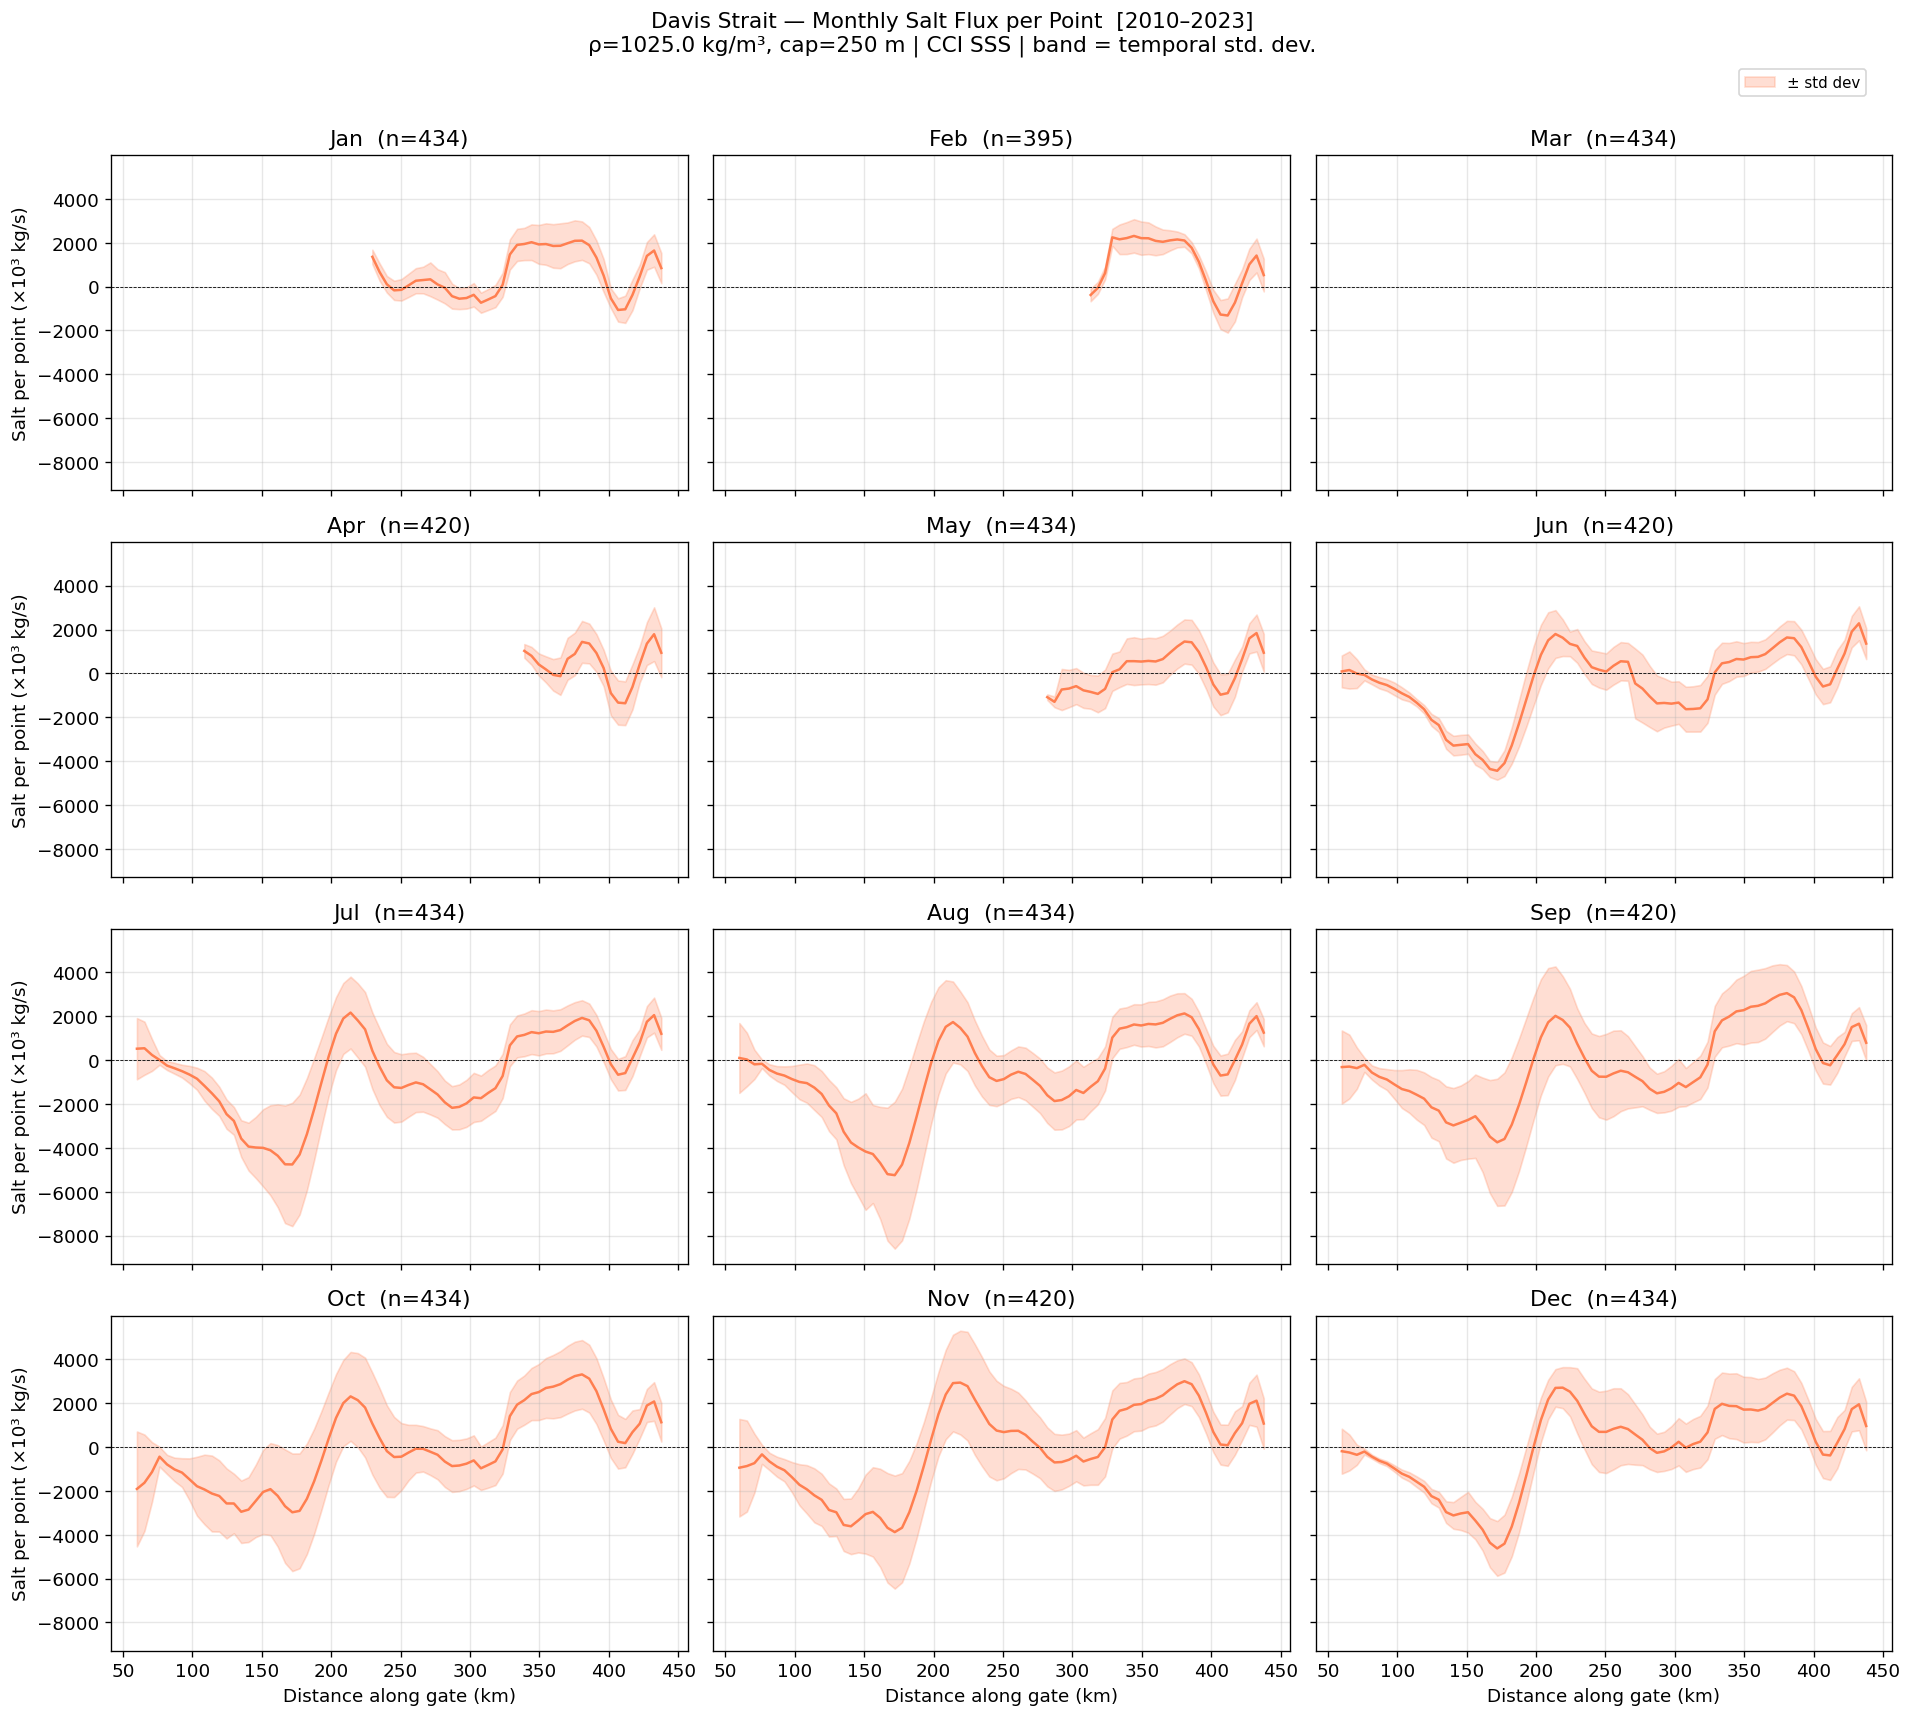

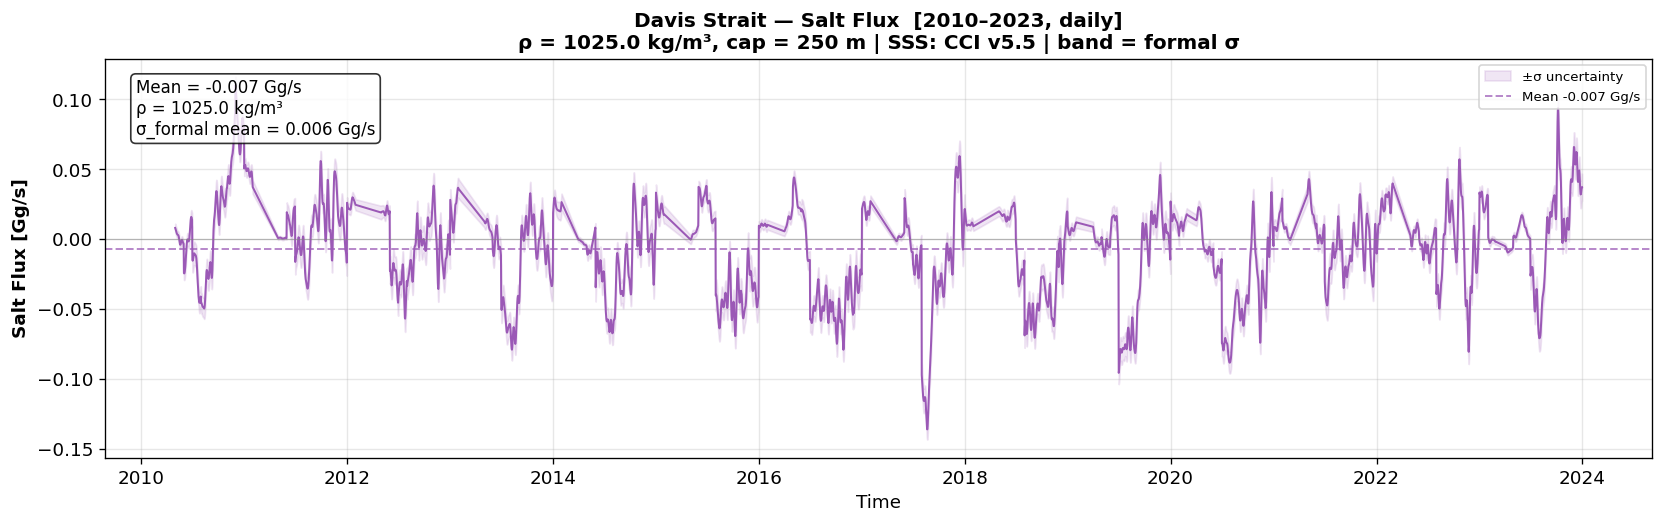

In [ ]:
if not has_sss:
    print('⚠️  No finite CCI SSS data — skip salt flux plots.')
else:
    sm_pp = salt_flux_per_point(ds, depth_cap=CAP, rho=RHO)              # kg/s
    sigma_sm_pp = salt_flux_per_point_uncertainty(ds, depth_cap=CAP, rho=RHO)
    sm_pp_kt = sm_pp / 1e3
    sigma_sm_pp_kt = sigma_sm_pp / 1e3

    sm_profiles = monthly_along_gate_profile(sm_pp_kt, time, x_km, sigma=sigma_sm_pp_kt)

    plot_monthly_grid(
        x_km=x_km,
        profiles=sm_profiles,
        y_label='Salt per point (×10³ kg/s)',
        color='coral',
        title=(
            f'{gate_name} — Monthly Salt Flux per Point  [{DATE_START[:4]}–{DATE_END[:4]}]<br>'
            f'<sup>ρ={RHO} kg/m³, cap={CAP} m | local per-point projection | band = temporal std. dev.</sup>'
        ),
        band_label='± std dev',
        zero_line=True,
    )

    sm, t_sm = salt_flux(ds, depth_cap=CAP, rho=RHO)
    sigma_sm = salt_flux_uncertainty(ds, depth_cap=CAP, rho=RHO)
    sm_ggs = sm / 1e9
    sigma_ggs = sigma_sm / 1e9

    col_salt = '#9B59B6'
    fig = go.Figure()
    valid = np.isfinite(sm_ggs)
    fig.add_trace(go.Scatter(x=t_sm[valid], y=sm_ggs[valid], mode='lines', line=dict(color=col_salt, width=1.5), name='Salt Flux'))

    valid_band = np.isfinite(sm_ggs) & np.isfinite(sigma_ggs)
    if np.any(valid_band):
        x_band = np.concatenate([t_sm[valid_band], t_sm[valid_band][::-1]])
        y_band = np.concatenate([(sm_ggs[valid_band] - sigma_ggs[valid_band]), (sm_ggs[valid_band] + sigma_ggs[valid_band])[::-1]])
        fig.add_trace(go.Scatter(x=x_band, y=y_band, fill='toself', fillcolor='rgba(155,89,182,0.15)',
                                 line=dict(color='rgba(0,0,0,0)'), name='±σ uncertainty', hoverinfo='skip'))

    mean_sm = float(np.nanmean(sm_ggs))
    fig.add_hline(y=mean_sm, line=dict(color=col_salt, width=1.2, dash='dash'))
    fig.add_hline(y=0.0, line=dict(color='gray', width=1, dash='dot'))

    fig.add_annotation(
        xref='paper', yref='paper', x=0.01, y=0.98, showarrow=False, align='left',
        text=(
            f'Mean = {mean_sm:+.3f} Gg/s<br>'
            f'σ_formal mean = {np.nanmean(sigma_ggs):.3f} Gg/s'
        ),
        bgcolor='rgba(255,255,255,0.85)'
    )

    fig.update_layout(
        title=(
            f'{gate_name} — Salt Flux  [{DATE_START[:4]}–{DATE_END[:4]}, daily]<br>'
            f'<sup>ρ={RHO} kg/m³, cap={CAP} m | local per-point projection</sup>'
        ),
        xaxis_title='Time',
        yaxis_title='Salt Flux [Gg/s]',
        template='plotly_white',
        height=420,
    )
    fig.show()